In [29]:
import numpy as np
import sys 
sys.path.append("../../src")
from project_imports import *


In [31]:
def gamma(t,T):
    return tanh(2/T(t))
def T(t):
    return -4*(log(1-g0)*(1-t/tau))**-1.

In [ ]:
import numpy as np

# 1D kinetic Ising chain with Glauber (heat-bath) single-spin-flip dynamics
# H = -J Σ s_i s_{i+1} - h Σ s_i,  s_i = ±1, periodic BC
#
# Glauber/heat-bath update:
#   ΔE_i = 2 s_i [ J (s_{i-1}+s_{i+1}) + h ]
#   P(flip i) = 1 / (1 + exp(β ΔE_i))
#
# "time" here is in Monte Carlo sweeps (MCS): 1 MCS = N random updates.

def deltaE_1d(s, i, J=1.0, h=0.0):
    N = s.size
    left  = s[(i - 1) % N]
    right = s[(i + 1) % N]
    return 2.0 * s[i] * (J * (left + right) + h)

def glauber_sweep(s, beta, J=1.0, h=0.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = s.size
    for _ in range(N):
        i = rng.integers(N)
        dE = deltaE_1d(s, i, J=J, h=h)
        # stable accept prob
        if dE <= 0.0:
            p = 1.0
        else:
            p = 1.0 / (1.0 + np.exp(beta * dE))
        if rng.random() < p:
            s[i] = -s[i]
    return s

def kink_density(s):
    # fraction of domain walls (bonds with s_i != s_{i+1})
    return 0.5 * np.mean(1.0 - s * np.roll(s, -1))

def T_linear(t, Ti, Tf, tau):
    # t, tau in MCS; linear ramp then hold
    if t <= 0:
        return Ti
    if t >= tau:
        return Tf
    return Ti + (Tf - Ti) * (t / tau)

def run_glauber_quench(
    N=512,
    J=1.0,
    h=0.0,
    Ti=5.0,          # initial temperature
    Tf=1.0,          # final temperature
    tau=2000,        # ramp duration in MCS
    T_total=5000,    # total duration in MCS
    init="random",   # "random" or "all_up"
    seed=0,
    measure_every=1
):
    rng = np.random.default_rng(seed)

    if init == "random":
        s = rng.choice([-1, 1], size=N).astype(np.int8)
    elif init == "all_up":
        s = np.ones(N, dtype=np.int8)
    else:
        raise ValueError("init must be 'random' or 'all_up'")

    n_steps = int(T_total)
    times = np.arange(0, n_steps + 1, measure_every, dtype=int)
    m = np.empty(times.size, dtype=float)
    rho = np.empty(times.size, dtype=float)
    Ts = np.empty(times.size, dtype=float)

    out_idx = 0
    for t in range(n_steps + 1):
        if t % measure_every == 0:
            m[out_idx] = np.mean(s)
            rho[out_idx] = kink_density(s)
            Ts[out_idx] = T_linear(t, Ti, Tf, tau)
            out_idx += 1

        if t == n_steps:
            break

        Tt = T_linear(t, Ti, Tf, tau)
        beta = np.inf if Tt <= 0 else 1.0 / Tt
        glauber_sweep(s, beta, J=J, h=h, rng=rng)

    return times, Ts, m, rho, s
taus= np.logspace(0,3,100)
dat=[]
for t in taus:
    times, Ts, m, rho, s_final = run_glauber_quench(
        N=512, J=1.0, h=0.0,
        Ti=5.0, Tf=0.0,
        tau=t, T_total=4*t,
        init="random", seed=1, measure_every=5
    )
    print("Final T =", Ts[-1])
    print("Final m =", m[-1])
    print("Final kink density =", rho[-1])
    dat.append(rho[-1])


Final T = 5.0
Final m = 0.0234375
Final kink density = 0.5078125
Final T = 5.0
Final m = 0.0234375
Final kink density = 0.5078125
Final T = 5.0
Final m = 0.0234375
Final kink density = 0.5078125
Final T = 5.0
Final m = 0.0234375
Final kink density = 0.5078125
Final T = 0.0
Final m = -0.0390625
Final kink density = 0.1328125
Final T = 0.0
Final m = -0.05078125
Final kink density = 0.125
Final T = 0.0
Final m = -0.05078125
Final kink density = 0.125
Final T = 0.0
Final m = -0.0859375
Final kink density = 0.125
Final T = 0.0
Final m = -0.0859375
Final kink density = 0.125
Final T = 0.0
Final m = -0.09375
Final kink density = 0.1328125
Final T = 0.0
Final m = -0.078125
Final kink density = 0.1484375
Final T = 0.0
Final m = -0.09765625
Final kink density = 0.15234375
Final T = 0.0
Final m = -0.09765625
Final kink density = 0.15234375
Final T = 0.0
Final m = -0.078125
Final kink density = 0.15234375
Final T = 0.0
Final m = -0.140625
Final kink density = 0.09375
Final T = 0.0
Final m = -0.179

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_18145/2176391580.py:29: RuntimeWarning: overflow encountered in exp
  p = 1.0 / (1.0 + np.exp(beta * dE))


Final T = 0.0
Final m = -0.9140625
Final kink density = 0.00390625
Final T = 0.0
Final m = -0.26171875
Final kink density = 0.01171875
Final T = 0.0
Final m = 0.3984375
Final kink density = 0.0078125
Final T = 0.0
Final m = -0.2265625
Final kink density = 0.00390625
Final T = 0.0
Final m = 0.50390625
Final kink density = 0.0078125
Final T = 0.0
Final m = -0.30859375
Final kink density = 0.0078125
Final T = 0.0
Final m = -0.4453125
Final kink density = 0.00390625
Final T = 0.0
Final m = -0.87109375
Final kink density = 0.00390625
Final T = 0.0
Final m = -0.0546875
Final kink density = 0.0078125
Final T = 0.0
Final m = 0.1328125
Final kink density = 0.00390625
Final T = 0.0
Final m = 0.1953125
Final kink density = 0.00390625
Final T = 0.0
Final m = -0.21484375
Final kink density = 0.00390625
Final T = 0.0
Final m = -0.6640625
Final kink density = 0.00390625
Final T = 0.0
Final m = 0.515625
Final kink density = 0.0078125
Final T = 0.0
Final m = 0.53515625
Final kink density = 0.00390625
F

[]

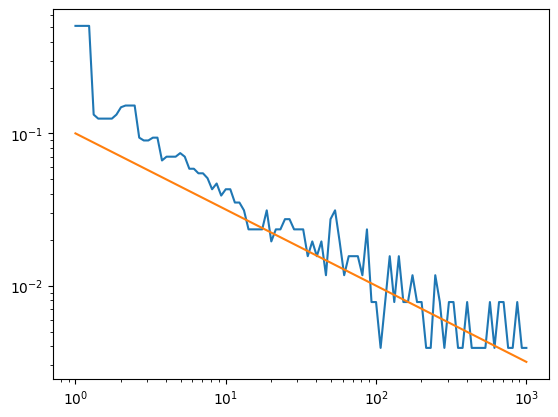

In [48]:
plot(taus,dat)
plot(taus,taus**(-1/2)/10)
loglog()

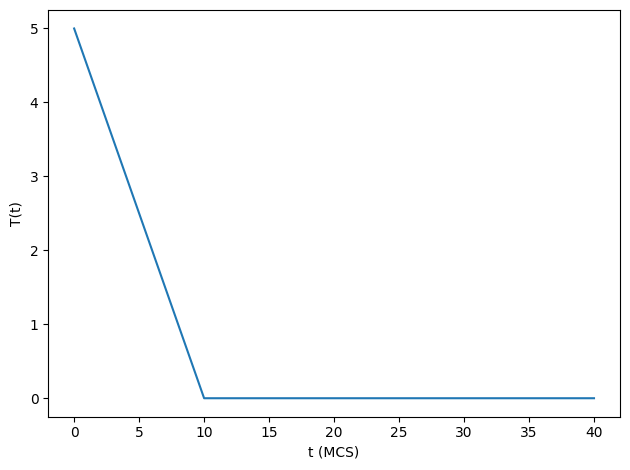

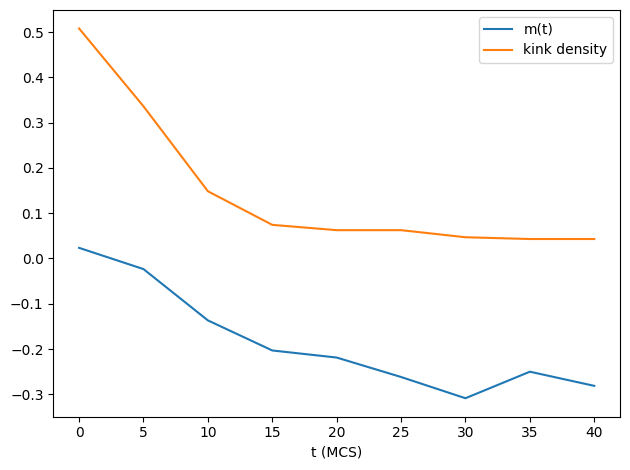

In [37]:
# plotting (optional)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(times, Ts)
plt.xlabel("t (MCS)")
plt.ylabel("T(t)")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(times, m, label="m(t)")
plt.plot(times, rho, label="kink density")
plt.xlabel("t (MCS)")
plt.legend()
plt.tight_layout()
plt.show()


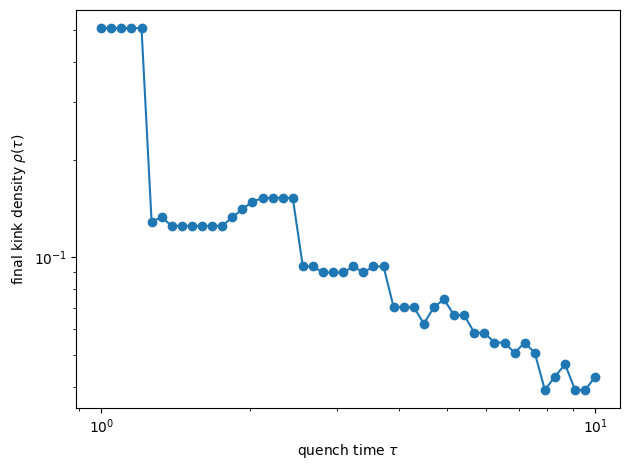

In [51]:
import matplotlib.pyplot as plt

taus = np.logspace(0, 1, 50)
dat = []

for t in taus:
    times, Ts, m, rho, s_final = run_glauber_quench(
        N=512, J=1.0, h=0.0,
        Ti=5.0, Tf=0.0,
        tau=t, T_total=4*t,
        init="random", seed=1, measure_every=5
    )
    dat.append(rho[-1])

taus = np.array(taus)
dat = np.array(dat)

plt.figure()
plt.loglog(taus, dat, "o-")
plt.xlabel(r"quench time $\tau$")
plt.ylabel(r"final kink density $\rho(\tau)$")
plt.tight_layout()
plt.show()


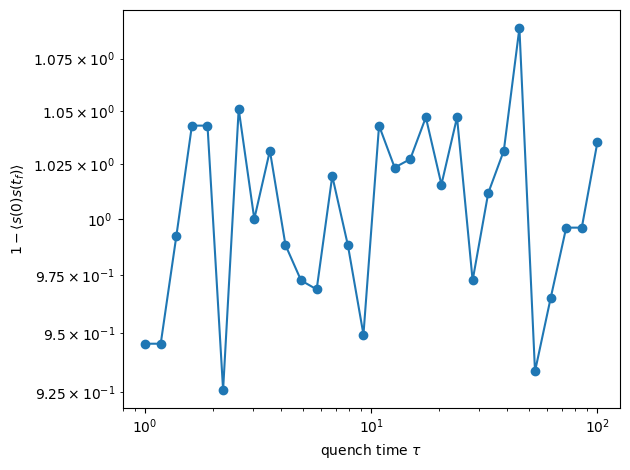

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Glauber dynamics ----------------

def deltaE_1d(s, i, J=1.0, h=0.0):
    N = s.size
    return 2.0 * s[i] * (J * (s[(i-1) % N] + s[(i+1) % N]) + h)

def glauber_sweep(s, beta, J=1.0, h=0.0, rng=None):
    N = s.size
    for _ in range(N):
        i = rng.integers(N)
        dE = deltaE_1d(s, i, J, h)
        if dE <= 0 or rng.random() < 1.0 / (1.0 + np.exp(beta * dE)):
            s[i] *= -1
    return s

def T_linear(t, Ti, Tf, tau):
    if t >= tau:
        return Tf
    return Ti + (Tf - Ti) * t / tau

# ---------------- Main loop ----------------

N = 512
J = 1.0
Ti = 5.0
Tf = 0.0
taus = np.logspace(0, 2, 30)

return_prob = []

for tau in taus:
    rng = np.random.default_rng(1)

    # initial state
    s = rng.choice([-1, 1], size=N).astype(np.int8)
    s0 = s.copy()

    T_total = int(4 * tau)

    for t in range(T_total):
        Tt = T_linear_heat(t, Ti, Tf, tau)
        beta = np.inf if Tt == 0 else 1.0 / Tt
        glauber_sweep(s, beta, J=J, rng=rng)

    R = np.mean(s0 * s)
    return_prob.append(1.0 - R)

# ---------------- Plot ----------------

return_prob = np.array(return_prob)

plt.figure()
plt.loglog(taus, return_prob, "o-")
plt.xlabel(r"quench time $\tau$")
plt.ylabel(r"$1-\langle s(0)s(t_f)\rangle$")
plt.tight_layout()
plt.show()


tau = 0.1 final rho = 0.38953097452139473
tau = 50.0 final rho = 0.2689414213699949
tau = 200.0 final rho = 0.2689414213699949


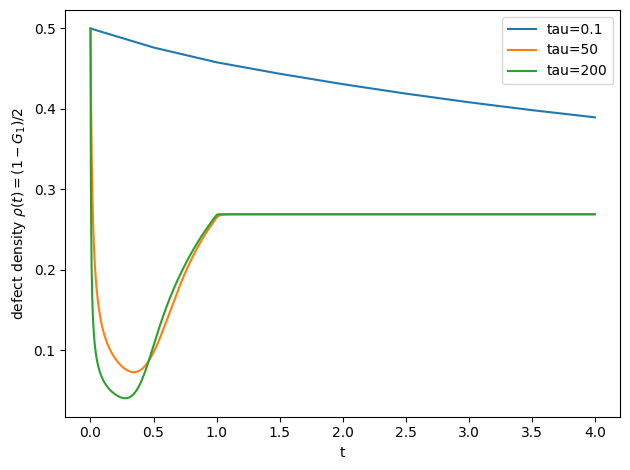

In [72]:
import numpy as np

# Deterministic Glauber-chain correlators:
# dG_k/dt = -2 G_k + gamma(t) [G_{k-1} + G_{k+1}],  k=1..K
# with boundary G_0(t)=1 and (approx) G_{K+1}(t)=G_K(t) (large-K cutoff).
#
# gamma(t) = tanh(2J/T(t))   (k_B = 1)
#
# You can change the quench time tau in T_of_t.

def gamma_of_t(t, T_of_t, J=1.0):
    T = T_of_t(t)
    if T <= 0.0:
        return 1.0
    x = 2.0 * J / T
    if x > 40.0:   # avoid overflow, tanh(x) ~ 1
        return 1.0
    return np.tanh(x)

def T_linear_quench(t, Ti, Tf, tau):
    # linear ramp Ti -> Tf over time tau, then hold at Tf
    if t <= 0.0:
        return Ti
    if t >= tau:
        return Tf
    return Ti + (Tf - Ti) * (t / tau)
def T_linear_heat(t, Ti=0.0, Tf=5.0, tau=200.0):
    if t <= 0.0:
        return Ti
    if t >= tau:
        return Tf
    return Ti + (Tf - Ti) * (t / tau)

def rhs_G(G, t, K, T_of_t, J=1.0):
    # G is length K array holding [G_1,...,G_K]
    gam = gamma_of_t(t, T_of_t, J=J)

    dG = np.empty_like(G)

    # boundary values
    G0 = 1.0
    # large-K closure: G_{K+1} ≈ G_K  (alternatively set 0 for high-T)
    GKp1 = G[-1]

    # k=1
    dG[0] = -2.0 * G[0] + gam * (G0 + G[1] if K > 1 else G0 + GKp1)

    # 1<k<K
    for k in range(2, K):
        dG[k-1] = -2.0 * G[k-1] + gam * (G[k-2] + G[k])

    # k=K
    if K > 1:
        dG[K-1] = -2.0 * G[K-1] + gam * (G[K-2] + GKp1)

    return dG

def evolve_Gk(
    K=200,
    J=1.0,
    Ti=5.0,
    Tf=0.2,
    tau=200.0,
    t_max=None,
    dt=0.05,
    init="highT",   # "highT" => G_k(0)=0 (k>=1); "custom" allowed below
    G_init=None
):
    # time grid
    if t_max is None:
        t_max = 2.0 * tau
    n_steps = int(np.ceil(t_max / dt))
    ts = np.linspace(0.0, n_steps * dt, n_steps + 1)

    # initial condition
    if init == "highT":
        G = np.zeros(K, dtype=float)
    elif init == "custom":
        if G_init is None or len(G_init) != K:
            raise ValueError("For init='custom', provide G_init length K for [G1..GK].")
        G = np.array(G_init, dtype=float).copy()
    else:
        raise ValueError("init must be 'highT' or 'custom'.")

    # storage
    G_hist = np.empty((ts.size, K), dtype=float)
    rho = np.empty(ts.size, dtype=float)  # defect density D(t) = (1-G1)/2
    gammas = np.empty(ts.size, dtype=float)
    temps = np.empty(ts.size, dtype=float)

    # quench protocol
    T_of_t = lambda t: T_linear_heat(t, Ti=Ti, Tf=Tf, tau=tau)

    # RK4 integration
    for n, t in enumerate(ts):
        G_hist[n] = G
        rho[n] = 0.5 * (1.0 - G[0])
        temps[n] = T_of_t(t)
        gammas[n] = gamma_of_t(t, T_of_t, J=J)

        if n == ts.size - 1:
            break

        k1 = rhs_G(G, t, K, T_of_t, J=J)
        k2 = rhs_G(G + 0.5 * dt * k1, t + 0.5 * dt, K, T_of_t, J=J)
        k3 = rhs_G(G + 0.5 * dt * k2, t + 0.5 * dt, K, T_of_t, J=J)
        k4 = rhs_G(G + dt * k3, t + dt, K, T_of_t, J=J)
        G = G + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        # optional: keep within [-1,1] to control numerical drift
        np.clip(G, -1.0, 1.0, out=G)

    return ts, temps, gammas, G_hist, rho
def block_rate(G_row, n):
    return -(1.0/n)*np.sum(np.log((1.0 + G_row[:n-1]) / 2.0))

# Example usage:
if __name__ == "__main__":
    taus = [0.1, 50.0, 200.0]
    out = []
    for tau in taus:
        ts, Tt, gam, G_hist, rho = evolve_Gk(
            K=400, J=1.0, Ti=0.0, Tf=2.0, tau=tau,
            t_max=4*tau, dt=0.05, init="highT"
        )
        out.append((tau, ts, rho))
        print("tau =", tau, "final rho =", rho[-1])

    # Plot defect density vs time for each tau (optional)
    import matplotlib.pyplot as plt
    plt.figure()
    for tau, ts, rho in out:
        plt.plot(ts/tau, rho, label=f"tau={tau:g}")
    plt.xlabel("t")
    plt.ylabel(r"defect density $\rho(t)=(1-G_1)/2$")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [69]:
# run the deterministic evolution
ts, Tt, gam, G_hist, rho = evolve_Gk(
    K=400, J=1.0, Ti=0.0, Tf=5.0, tau=tau,
    t_max=4*tau, dt=0.05, init="highT"
)



In [70]:

# choose block size n (n <= K+1)
n = 10

# compute LE-like block rate at each time
lambda_n = np.array([
    -(1.0/n) * np.sum(np.log((1.0 + G_row[:n-1]) / 2.0))
    for G_row in G_hist
])


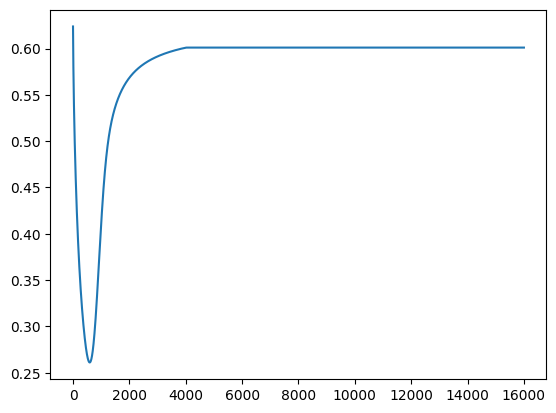

In [71]:
plot(lambda_n)

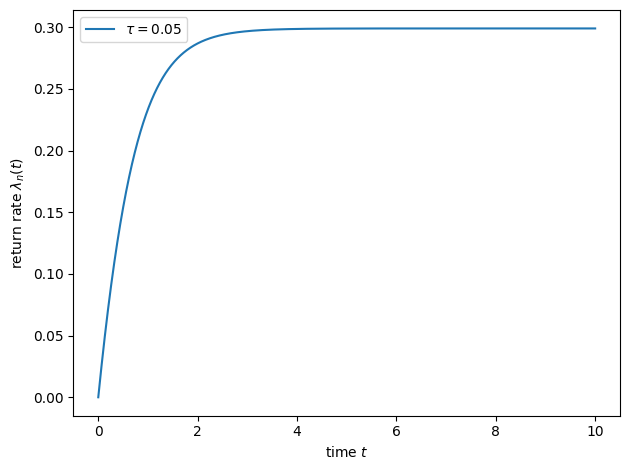

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Temperature protocol: heating quench
# T = 0 --> Tf over time tau
# -----------------------------
def T_heat(t, T0,Tf=10.0, tau=1.0):
    if t <= tau:
        return T0
    if t >= tau:
        return Tf
    return Tf * t / tau

def gamma_of_t(t,T0, Tf, tau, J=1.0):
    T = T_heat(t, T0=T0,Tf=Tf, tau=tau)
    if T <= 0.0:
        return 1.0
    x = 2.0 * J / T
    return 1.0 if x > 40 else np.tanh(x)

# -----------------------------
# RHS of G_k hierarchy
# -----------------------------
def rhs_G(G, t, T0,Tf, tau, J=1.0):
    K = len(G)
    g = gamma_of_t(t, T0,Tf, tau, J)

    dG = np.zeros_like(G)
    G0 = 1.0
    GKp1 = G[-1]      # large-k closure

    # k = 1
    dG[0] = -2*G[0] + g*(G0 + (G[1] if K > 1 else GKp1))

    # 1 < k < K
    for k in range(1, K-1):
        dG[k] = -2*G[k] + g*(G[k-1] + G[k+1])

    # k = K
    if K > 1:
        dG[-1] = -2*G[-1] + g*(G[-2] + GKp1)

    return dG

# -----------------------------
# Integrate G_k
# -----------------------------
def evolve_Gk_heating(
    K=300,
    T0=0,
    Tf=10.0,
    tau=0.2,
    t_max=2.0,
    dt=1e-3,
    J=1.0
):
    ts = np.arange(0.0, t_max + dt, dt)

    # Initial condition: perfect order (T=0)
    G = np.ones(K)

    G_hist = np.zeros((len(ts), K))

    for i, t in enumerate(ts):
        G_hist[i] = G
        if i == len(ts) - 1:
            break

        # RK4
        k1 = rhs_G(G, t, T0,Tf, tau, J)
        k2 = rhs_G(G + 0.5*dt*k1, t + 0.5*dt, T0,Tf, tau, J)
        k3 = rhs_G(G + 0.5*dt*k2, t + 0.5*dt,T0, Tf, tau, J)
        k4 = rhs_G(G + dt*k3, t + dt, T0,Tf, tau, J)
        G += (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

        np.clip(G, -1.0, 1.0, out=G)

    return ts, G_hist

# -----------------------------
# Block return probability
# -----------------------------
def block_rate(G_row, n):
    return -(1.0/n)*np.sum(np.log((1.0 + G_row[:n-1]) / 2.0))

# -----------------------------
# Main: short quenches
# -----------------------------
taus = [0.05]   # emphasize short quenches
Tf = 10
n_block = 2

plt.figure()

for tau in taus:
    ts, G_hist = evolve_Gk_heating(
        K=30, T0=10,Tf=Tf, tau=tau, t_max=10.0, dt=1e-3
    )

    lambda_n = np.array([block_rate(G, n_block) for G in G_hist])
    plt.plot(ts, lambda_n, label=rf"$\tau={tau}$")

plt.xlabel("time $t$")
plt.ylabel(r"return rate $\lambda_n(t)$")
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_18145/240696553.py:133: RuntimeWarning: divide by zero encountered in matmul
  pt = expm(Wsf * dt) @ p0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_18145/240696553.py:133: RuntimeWarning: overflow encountered in matmul
  pt = expm(Wsf * dt) @ p0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_18145/240696553.py:133: RuntimeWarning: invalid value encountered in matmul
  pt = expm(Wsf * dt) @ p0


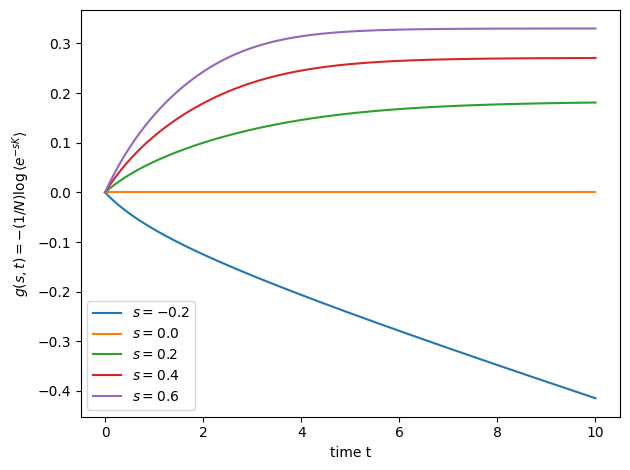

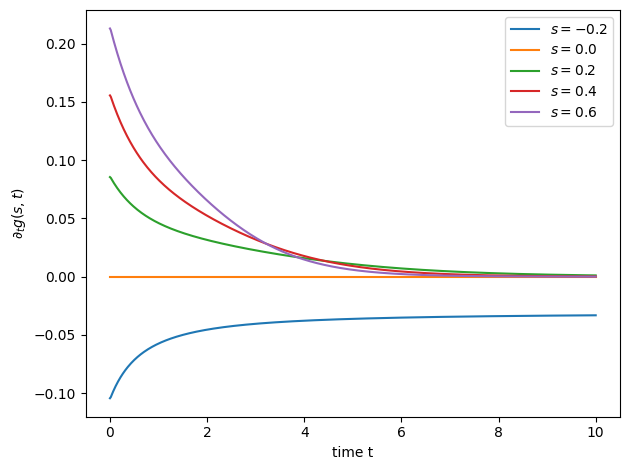

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from scipy.linalg import expm

# -----------------------------
# 1D periodic Ising chain, continuous-time Glauber dynamics (heat-bath form)
# Configuration C is a bitstring of length N representing spins s_i = ±1.
#
# Glauber flip rate for site i in configuration s:
#   w_i(s; T) = 0.5 * [ 1 - (gamma(T)/2) * s_i*(s_{i-1}+s_{i+1}) ]
# where gamma(T) = tanh(2J/T). (k_B=1)
#
# Generator W has off-diagonals: W(C'|C)=w_i if C' differs by flipping site i
# and diagonal: W(C|C) = -sum_i w_i.
#
# Tilted generator for ACTIVITY K (count each flip as +1):
#   W_s(C'|C) = e^{-s} * W(C'|C) for C'!=C; diagonals unchanged.
#
# Dynamical partition function after quench at time t0:
#   Z(s,t) = 1^T exp(W_s(Tf) * (t - t0)) p(t0) ,  t>=t0
# Dynamical free energy density (LE-analogue):
#   g(s,t) = -(1/N) log Z(s,t)
# Cusps (DQPT-like) appear from eigenvalue competition in large N.
# -----------------------------

def gamma_T(T, J=1.0):
    if T <= 0.0:
        return 1.0
    x = 2.0 * J / T
    return 1.0 if x > 40.0 else np.tanh(x)

def idx_to_spins(idx, N):
    # idx in [0, 2^N)
    # bit=0 -> -1, bit=1 -> +1
    s = np.empty(N, dtype=np.int8)
    for i in range(N):
        bit = (idx >> i) & 1
        s[i] = 1 if bit else -1
    return s

def flip_bit(idx, i):
    return idx ^ (1 << i)

def glauber_rate_for_site(s, i, gam):
    N = len(s)
    nn = s[(i - 1) % N] + s[(i + 1) % N]
    return 0.5 * (1.0 - 0.5 * gam * s[i] * nn)

def build_generator_W(N, T, J=1.0):
    dim = 1 << N
    gam = gamma_T(T, J=J)

    W = np.zeros((dim, dim), dtype=np.float64)

    for C in range(dim):
        s = idx_to_spins(C, N)
        rates = np.array([glauber_rate_for_site(s, i, gam) for i in range(N)], dtype=np.float64)
        out = rates.sum()
        W[C, C] = -out
        for i in range(N):
            Cp = flip_bit(C, i)
            W[Cp, C] += rates[i]
    return W

def tilt_activity(W, s_field):
    # off-diagonals multiplied by exp(-s_field), diagonals unchanged
    Ws = W.copy()
    dim = W.shape[0]
    fac = np.exp(-s_field)
    for j in range(dim):
        for i in range(dim):
            if i != j and Ws[i, j] != 0.0:
                Ws[i, j] *= fac
    return Ws

def equilibrium_dist(N, T, J=1.0):
    # exact equilibrium for small N: p(C) ∝ exp(-H(C)/T), with H = -J sum s_i s_{i+1}
    dim = 1 << N
    beta = np.inf if T <= 0 else 1.0 / T
    E = np.empty(dim, dtype=np.float64)
    for C in range(dim):
        s = idx_to_spins(C, N).astype(np.int8)
        E[C] = -J * np.sum(s * np.roll(s, -1))
    if np.isinf(beta):
        # T=0: equal weight on the two ferromagnetic ground states
        # ground states are all + and all -
        p = np.zeros(dim, dtype=np.float64)
        all_up = (1 << N) - 1
        all_dn = 0
        p[all_up] = 0.5
        p[all_dn] = 0.5
        return p
    w = np.exp(-beta * (E - E.min()))
    return w / w.sum()

def dyn_free_energy_activity(
    N=12,
    J=1.0,
    Ti=10.0,
    Tf=0.5,
    t0=0.0,
    t_grid=None,
    s_field=0.2,
    init="equilibrium",   # "equilibrium" at Ti, or "all_up"
):
    if t_grid is None:
        t_grid = np.linspace(t0, t0 + 10.0, 400)

    # initial distribution at time t0
    if init == "equilibrium":
        p0 = equilibrium_dist(N, Ti, J=J)
    elif init == "all_up":
        dim = 1 << N
        p0 = np.zeros(dim, dtype=np.float64)
        p0[(1 << N) - 1] = 1.0
    else:
        raise ValueError("init must be 'equilibrium' or 'all_up'")

    # Sudden quench at t0: evolve for t>=t0 with Tf
    Wf = build_generator_W(N, Tf, J=J)
    Wsf = tilt_activity(Wf, s_field)

    ones = np.ones(1 << N, dtype=np.float64)

    g = np.empty_like(t_grid, dtype=np.float64)
    for k, t in enumerate(t_grid):
        dt = t - t0
        if dt < 0:
            # before quench: define g using Ti evolution (rarely needed); keep constant here
            Z = 1.0
        else:
            pt = expm(Wsf * dt) @ p0
            Z = ones @ pt
        # avoid log(0) from numerical underflow
        Z = max(Z, 1e-300)
        g[k] = -(1.0 / N) * np.log(Z)
    return t_grid, g

# -----------------------------
# Demo: show DQPT-like cusps by scanning s_field
# Emphasize sudden quench and short post-quench times
# -----------------------------
if __name__ == "__main__":
    N = 8        # increase N to sharpen the cusp-like crossover
    J = .25
    Ti = 5.0       # high-T initial
    Tf = 0       # low-T final (across critical point if you think in 2D; here it's 1D kinetics)
    t0 = 0.0
    t_grid = np.linspace(t0, t0 + 10.0, 600)  # short times emphasized

    # choose s around where eigenvalue competition is strongest
    s_list = [-.2,0.0, 0.2, 0.4, 0.6]

    plt.figure()
    for s_field in s_list:
        t, g = dyn_free_energy_activity(
            N=N, J=J, Ti=Ti, Tf=Tf, t0=t0, t_grid=t_grid, s_field=s_field, init="equilibrium"
        )
        plt.plot(t, g, label=fr"$s={s_field}$")
    plt.xlabel("time t")
    plt.ylabel(r"$g(s,t)=-(1/N)\log \langle e^{-sK}\rangle$")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional: plot time-derivative to make cusp/crossover visible
    plt.figure()
    for s_field in s_list:
        t, g = dyn_free_energy_activity(
            N=N, J=J, Ti=Ti, Tf=Tf, t0=t0, t_grid=t_grid, s_field=s_field, init="equilibrium"
        )
        dgdt = np.gradient(g, t)
        plt.plot(t, dgdt, label=fr"$s={s_field}$")
    plt.xlabel("time t")
    plt.ylabel(r"$\partial_t g(s,t)$")
    plt.legend()
    plt.tight_layout()
    plt.show()
